In [20]:
%pip install gradio

import os
import operator
import sqlite3
from typing import TypedDict, Annotated, Literal
import gradio as gr


Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: gradio in c:\users\potnu\appdata\local\programs\python\python313\lib\site-packages (6.2.0)




[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_openai import ChatOpenAI
from langchain_core.tools import Tool
from langchain_core.messages import HumanMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

In [22]:
class State(TypedDict):
    message: str

def city_a(state: State) -> State:
    print("City A")
    return {"message": state["message"] + " --> visited A"}

def city_b(state: State) -> State:
    print("City B")
    return {"message": state["message"] + " --> visited B"} 
  

In [23]:
graph = StateGraph(State)
graph.add_node("A", city_a)
graph.add_node("B", city_b)
graph.add_edge(START, "A")
graph.add_edge("A", "B")
graph.add_edge("B", END)

In [24]:
app = graph.compile()

result= app.invoke({"message": "Starting"})
print(f"\n Final: {result['message']}")

City A
City B

 Final: Starting --> visited A --> visited B


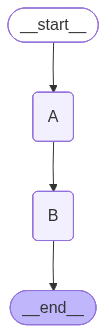

In [25]:
graph_image = app.get_graph().draw_mermaid_png()
display(Image(graph_image))

In [26]:
#reducer
class State(TypedDict):
    scores: Annotated[list[int],operator.add]

def node_a(state: State) -> State:
    return {"scores": [10, 20]}
def node_b(state: State) -> State:
    return {"scores": [40, 50]}

graph = StateGraph(State)
graph.add_node("a", node_a)
graph.add_node("b", node_b)
graph.add_edge(START, "a")
graph.add_edge(START, "b")
graph.add_edge("a", END)
graph.add_edge("b", END)




In [27]:
app = graph.compile()
result = app.invoke({"scores": []}) # pyright: ignore[reportArgumentType]

print("Scores (with operator.add reducer): ", result["scores"])


Scores (with operator.add reducer):  [10, 20, 40, 50]


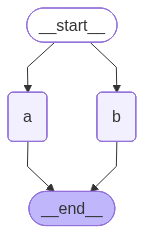

In [28]:
graph_image = app.get_graph().draw_mermaid_png()
display(Image(graph_image))

Full conversation:
  [human]: What is LangGraph?
  [ai]: Analysis: 'What is LangGraph?' looks like a question
  [ai]: Here's my answer based on the analysis...


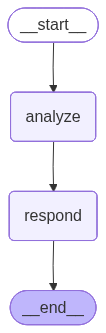

In [29]:
# ========== STATE FOR AGENT ==========
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

# ========== AGENT NODES ==========
def analyzer_agent(state: AgentState):
    """Analyzes user input"""
    last_message = state["messages"][-1].content

    return {
        "messages": [AIMessage(content=f"Analysis: '{last_message}' looks like a question")]
    }

def responder_agent(state: AgentState):
    """Responds based on analysis"""
    return {
        "messages": [AIMessage(content="Here's my answer based on the analysis...")]
    }

# ========== BUILD GRAPH ==========
graph = StateGraph(AgentState)
graph.add_node("analyze", analyzer_agent)
graph.add_node("respond", responder_agent)

graph.add_edge(START, "analyze")
graph.add_edge("analyze", "respond")
graph.add_edge("respond", END)

app = graph.compile()

# ========== RUN ==========
result = app.invoke({
    "messages": [HumanMessage(content="What is LangGraph?")]
})

print("Full conversation:")
for msg in result["messages"]:
    print(f"  [{msg.type}]: {msg.content}")

# Generate and display the graph
graph_image = app.get_graph().draw_mermaid_png()
display(Image(graph_image))

In [ ]:
# ========== SIMPLE TOOL ==========
from langchain_core.tools import tool


@tool
def send_notification(message: str) -> str:
    """Send a notification with a message"""
    print(f"📩 Notification sent: {message}")
    return f"Sent: {message}"

# ========== STATE ==========
class State(TypedDict):
    messages: Annotated[list, add_messages]

# ========== LLM WITH TOOLS ==========
tools = [send_notification]
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

# ========== NODES ==========
def chatbot(state: State):
    """LLM decides whether to use tools"""
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

tool_node = ToolNode(tools)

# ========== BUILD GRAPH ==========
graph = StateGraph(State)
graph.add_node("chatbot", chatbot)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chatbot")
graph.add_conditional_edges("chatbot", tools_condition)
graph.add_edge("tools", "chatbot")

app = graph.compile()

# ========== RUN ==========
result = app.invoke({
    "messages": [HumanMessage(content="Send me a notification saying 'Hello World'")]
})

print("\nFinal messages:")
for msg in result["messages"]:
    print(f"  {msg.type}: {msg.content}")

# Generate and display the graph
graph_image = app.get_graph().draw_mermaid_png()
display(Image(graph_image))

🔍 Scraping webpage...
⚠️ Only 1 pages. Need more!
🔍 Scraping webpage...
⚠️ Only 2 pages. Need more!
🔍 Scraping webpage...
✅ Got 3 pages. Ready!
✅ Enough info! Giving answer...

📄 Pages scraped: 3
💬 Answer: Answer based on 3 pages


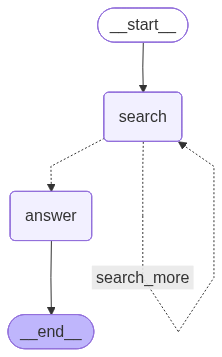

In [30]:
# STATE
class State(TypedDict):
    question: str
    info_collected: list[str]
    answer: str

# NODES
def search_page(state: State):
    """Scrape a webpage"""
    print("🔍 Scraping webpage...")
    new_info = f"Info from page {len(state['info_collected']) + 1}"
    return {"info_collected": state["info_collected"] + [new_info]}

def give_answer(state: State):
    """Provide final answer"""
    print("✅ Enough info! Giving answer...")
    return {"answer": f"Answer based on {len(state['info_collected'])} pages"}

# ROUTING FUNCTION - Do we have enough info?
def check_if_enough(state: State) -> Literal["search_more", "answer"]:
    """Decide: need more info or ready to answer?"""
    if len(state["info_collected"]) < 3:
        print(f"⚠️ Only {len(state['info_collected'])} pages. Need more!")
        return "search_more"
    else:
        print(f"✅ Got {len(state['info_collected'])} pages. Ready!")
        return "answer"

# BUILD GRAPH
graph = StateGraph(State)
graph.add_node("search", search_page)
graph.add_node("answer", give_answer)

graph.add_edge(START, "search")

# CONDITIONAL EDGE - Router decides: more scraping or answer?
graph.add_conditional_edges(
    "search",
    check_if_enough,
    {"search_more": "search", "answer": "answer"}  # Loop back or finish
)

graph.add_edge("answer", END)

app = graph.compile()

# RUN
result = app.invoke({
    "question": "What is LangGraph?",
    "info_collected": [],
    "answer": ""
})

print(f"\n📄 Pages scraped: {len(result['info_collected'])}")
print(f"💬 Answer: {result['answer']}")

# Generate and display the graph
graph_image = app.get_graph().draw_mermaid_png()
display(Image(graph_image))

Step 1 (superstep 1) - count: 0
Step 2 (superstep 2) - count: 1
Step 3 (superstep 3) - count: 2


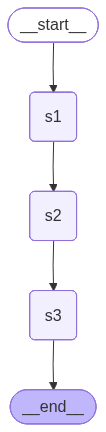

In [31]:
class State(TypedDict):
    count: int

def step_1(state: State):
    print(f"Step 1 (superstep 1) - count: {state['count']}")
    return {"count": state["count"] + 1}

def step_2(state: State):
    print(f"Step 2 (superstep 2) - count: {state['count']}")
    return {"count": state["count"] + 1}

def step_3(state: State):
    print(f"Step 3 (superstep 3) - count: {state['count']}")
    return {"count": state["count"] + 1}

graph = StateGraph(State)
graph.add_node("s1", step_1)
graph.add_node("s2", step_2)
graph.add_node("s3", step_3)

graph.add_edge(START, "s1")
graph.add_edge("s1", "s2")
graph.add_edge("s2", "s3")
graph.add_edge("s3", END)

app = graph.compile()

result = app.invoke({"count": 0})

# Generate and display the graph
graph_image = app.get_graph().draw_mermaid_png()
display(Image(graph_image))